In [3]:
import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical



In [4]:
# 1. Load Data

df = pd.read_csv("/content/marketing_sample_for_naukri_com-jobs__20190701_20190830__30k_data.csv")
print("Shape:", df.shape)
df.head(3)



Shape: (30000, 11)


,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive


In [7]:
# 2. Drop Duplicates

df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [8]:
# 3. Drop Missing Target / Feature Rows

df = df.dropna(subset=["Role Category", "Job Title", "Key Skills"])

In [9]:
# Keep only the top 15 most frequent Role Categories (rest are too rare to model)
top_categories = df["Role Category"].value_counts().head(15).index
df = df[df["Role Category"].isin(top_categories)].copy()
print("Shape after filtering to top 15 categories:", df.shape)

Shape after filtering to top 15 categories: (20973, 11)


In [10]:
# 4. Clean Text

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s|]", " ", text)     # keep only letters, spaces, pipes
    text = re.sub(r"\s+", " ", text).strip()   # collapse whitespace
    return text

df["combined_text"] = (
    df["Job Title"].fillna("") + " " +
    df["Key Skills"].fillna("") + " " +
    df["Location"].fillna("")
)
df["clean_text"] = df["combined_text"].apply(clean_text)

In [11]:
# 5. Encoder Labels

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Role Category"])
num_classes = df["label"].nunique()

In [12]:
# 6. Train / Test Split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

In [14]:
# 7. Prepare Sequences for the Neural Network

MAX_LEN = 40

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

y_train_arr = y_train.values
y_test_arr = y_test.values

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [16]:
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=64, mask_zero=True),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 9. Train
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

start = time.time()

history = lstm_model.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.5221 - loss: 1.7404 - val_accuracy: 0.6603 - val_loss: 1.2570
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.6699 - loss: 1.1477 - val_accuracy: 0.6865 - val_loss: 1.0426
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7132 - loss: 0.9450 - val_accuracy: 0.7294 - val_loss: 0.9349
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.7538 - loss: 0.8146 - val_accuracy: 0.7479 - val_loss: 0.8769
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7802 - loss: 0.7345 - val_accuracy: 0.7473 - val_loss: 0.8851
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8045 - loss: 0.6641 - val_accuracy: 0.7485 - val_loss: 0.8899
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8221 - loss: 0.6147 - val_accuracy: 0.7533 - val_loss: 0.9131


In [18]:
print(f"Training time: {time.time() - start:.2f}s")


Training time: 97.14s


In [19]:
# 10. Evaluate

y_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)

print(classification_report(y_test_arr, y_pred, target_names=label_encoder.classes_))
print("Accuracy:", accuracy_score(y_test_arr, y_pred))


132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
                                            precision    recall  f1-score   support

                                  Accounts       0.73      0.92      0.81       172
Admin/Maintenance/Security/Datawarehousing       0.45      0.43      0.44       182
                           Corporate Sales       0.00      0.00      0.00       139
                                  Creative       0.42      0.65      0.51        78
                        Engineering Design       0.89      0.11      0.20        71
                      HR/ Recruitment / IR       0.78      0.82      0.80       220
                                 Marketing       0.51      0.45      0.48        93
                      Medical Professional       0.68      0.70      0.69        82
                                     Other       0.22      0.02      0.04       170
      Production/Manufacturing/Maintenance       0.64      0.43      0.52       114
                      Programming

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
cm = confusion_matrix(y_test_arr, y_pred)

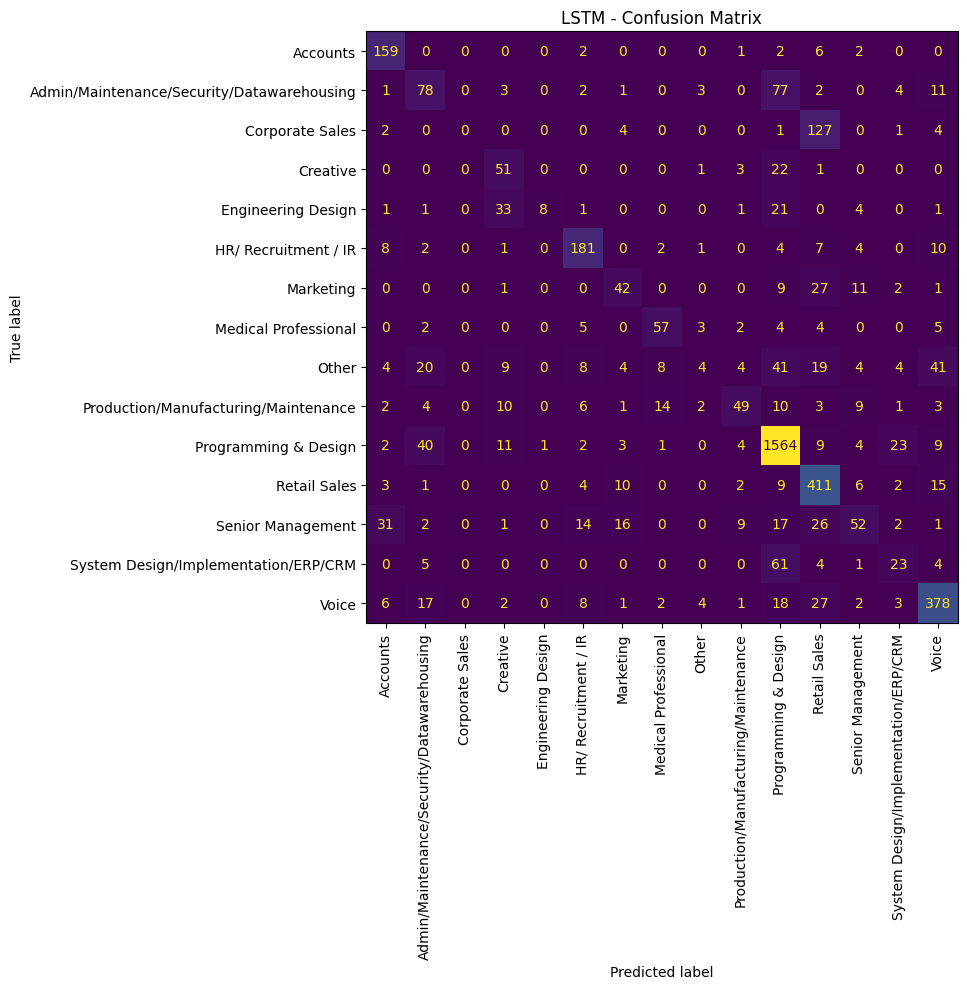

In [21]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("LSTM - Confusion Matrix")
plt.tight_layout()
plt.savefig("lstm_confusion_matrix.png")
plt.show()

In [ ]:
# 11. Save Artifacts

In [22]:
lstm_model.save("lstm_role_model.h5")

In [23]:

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Saved: lstm_role_model.h5, tokenizer.pkl, label_encoder.pkl")

Saved: lstm_role_model.h5, tokenizer.pkl, label_encoder.pkl
